# Find Contours in Video
This notebook uses the `find_contours.py` script to analyze video files and save contour results to a text file.

### First step is to manually identify where the tanks are in the video

This will be used later to identify the tanks as experimental replicates 

In [28]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

Figure(640x480)


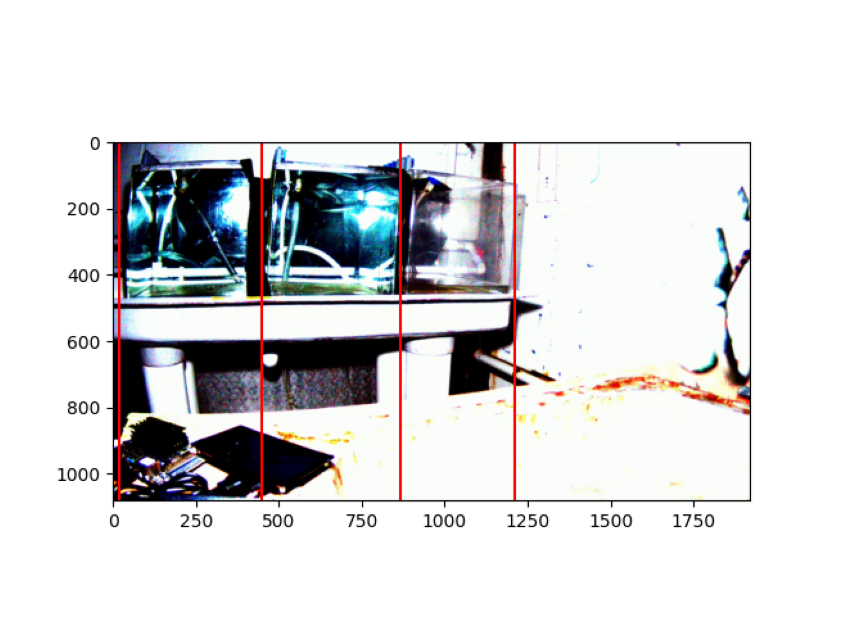

In [29]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Parameters
video_path = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part1.mp4'
frame_number = 500
x_lines = [20, 450, 865, 1210]
output_image = '../../results/041025PA_experimental.png'  # Save to results folder

# Build command
cmd = [
    'python3', '../../scripts/visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-o', output_image
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

### Next, plot overall brightness over time to inform threshold

In [ ]:
import subprocess
import os

# Parameters
#video_dir = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental'
video_file = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part10.mp4'
output_csv = '../../results/041025PA_experimental_brightness.csv'

# Run the script to generate the CSV for the exact file
subprocess.run([
    'python3', '../../scripts/brightnessOverTimeMB.py',
    '-f', video_file,
    '-v', '0',  # Don't show video window
    '-o', output_csv
], check=True)

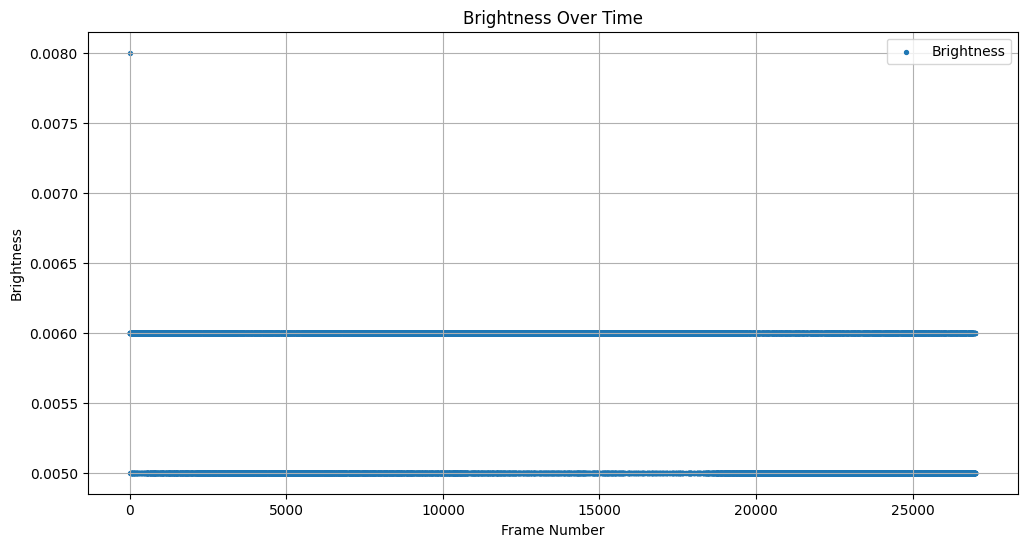

In [42]:
#Plot brightness over time

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV results
csv_path = '../../results/041025PA_experimental_brightness.csv'
df = pd.read_csv(csv_path, header=None)

# Plot frame (col 0) vs brightness (col 2) as points
plt.figure(figsize=(12, 6))
plt.scatter(df[0], df[2], label='Brightness', s=8)
plt.xlabel('Frame Number')
plt.ylabel('Brightness')
plt.title('Brightness Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# Set parameters for contour finding
video_pattern = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part1.mp4'
output_file = 'contours_041025PA_control.tab'
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 200
threads = 4
maxy = None

In [27]:
# Run contour finding and write results to file
results = find_contours_from_videos(
    video_pattern=video_pattern,
    black=black,
    minArea=minArea,
    maxArea=maxArea,
    brightnessThreshold=brightnessThreshold,
    threads=threads,
    outfile=output_file,
    maxy=maxy
)
print(f'Contour results written to {output_file}')

Processing videos:   0%|          | 0/1 [00:00<?, ?it/s]

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part1.mp4:…

KeyboardInterrupt: 